# Notebook 5: Evaluation & failure analysis (Phase 1 + Phase 2)

## Model assessment (tabular and optional image fusion)

This notebook visualizes **out-of-fold predictions** from `outputs/model_predictions.pkl` (Notebook 4; updated by Notebook 6 after Phase 2) and interprets them. Numeric tables in **§5.6** recompute from the pickle; narrative markdown may still quote an older run—adjust highlighted numbers after retraining.

**Clinical perspective:** missed melanoma (false negative) is usually weighted more heavily than unnecessary workup (false positive). The threshold section shows explicitly how sensitivity and false positives trade off on this cohort.


In [11]:
# ============================================================
# Setup
# ============================================================
import os, sys, warnings, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    confusion_matrix, classification_report, f1_score,
    precision_score, recall_score, average_precision_score
)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.figsize': (14, 6), 'font.size': 12})
SEED = 42

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    ROOT = '/content/drive/MyDrive/Skin-Cancer-Detection-ISIC-2024-'
else:
    ROOT = os.getcwd()

_SRC = os.path.abspath(os.path.join(ROOT, 'src'))
if _SRC not in sys.path:
    sys.path.insert(0, _SRC)

from isic_challenge.metrics import compute_pauc

FIG_DIR = os.path.join(ROOT, 'outputs', 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

pred_path = os.path.join(ROOT, 'outputs', 'model_predictions.pkl')
if os.path.exists(pred_path):
    with open(pred_path, 'rb') as f:
        pred_data = pickle.load(f)
    y = pred_data['y']
    lgb_oof = pred_data['lgb_oof']
    xgb_oof = pred_data['xgb_oof']
    tabular_oof = pred_data['tabular_oof']
    final_oof = pred_data['final_oof']
    img_oof = pred_data.get('img_oof')
    HAS_IMG = bool(pred_data.get('has_img', False)) and img_oof is not None
    phase = pred_data.get('phase', 'legacy')
    results_df = pred_data['results_df']
    feature_cols = pred_data['feature_cols']
    lgb_fi = pred_data['lgb_feature_importances']
    df_feat = pred_data['df_feat']
    display(Markdown(
        f"**Data loaded.** {len(y):,} rows, **{int(y.sum())}** malignant (`phase={phase!r}`, `has_img={HAS_IMG}`)."
    ))
else:
    raise FileNotFoundError(f"Run Notebook 4 first: {pred_path}")


**Data loaded.** 401,059 rows, **393** malignant (`phase='tabular_phase1'`, `has_img=False`).

## Results summary (this run)

**Authoritative numbers:** run **§5.6** below — it recomputes ROC-AUC, pAUC, and average precision for every model present in the pickle (tabular models; plus **EfficientNet** and **Full fusion** when `has_img=True` after Notebook 6).

**Cohort:** 401,059 lesions with **393** malignant labels (~0.098% prevalence).

**Headline (typical Phase 1 tabular run):** XGBoost usually beats LightGBM on ranking; the **OOF-weighted blend** adds a small gain. After Phase 2, compare image-only vs fusion in §5.6—fusion is chosen on OOF to maximize **pAUC** (probability vs logit blend).

**Ranking vs deployment:** High ROC-AUC does not imply high sensitivity at a “reasonable” alert rate. With ~400k benigns, even a strong model must either accept **many false alarms** to catch most cancers, or use a **high threshold** and miss a large share of positives. The PR curves, threshold table, and confusion matrix below make that trade-off concrete for *this* run’s **`final_oof`**.


## 5.1 ROC curve analysis

ROC shows overall separability; the second panel highlights the **high-sensitivity** region used for ISIC-style **pAUC (TPR ≥ 88%)**. Small differences in pAUC can matter when models are already strong in the full AUC sense.


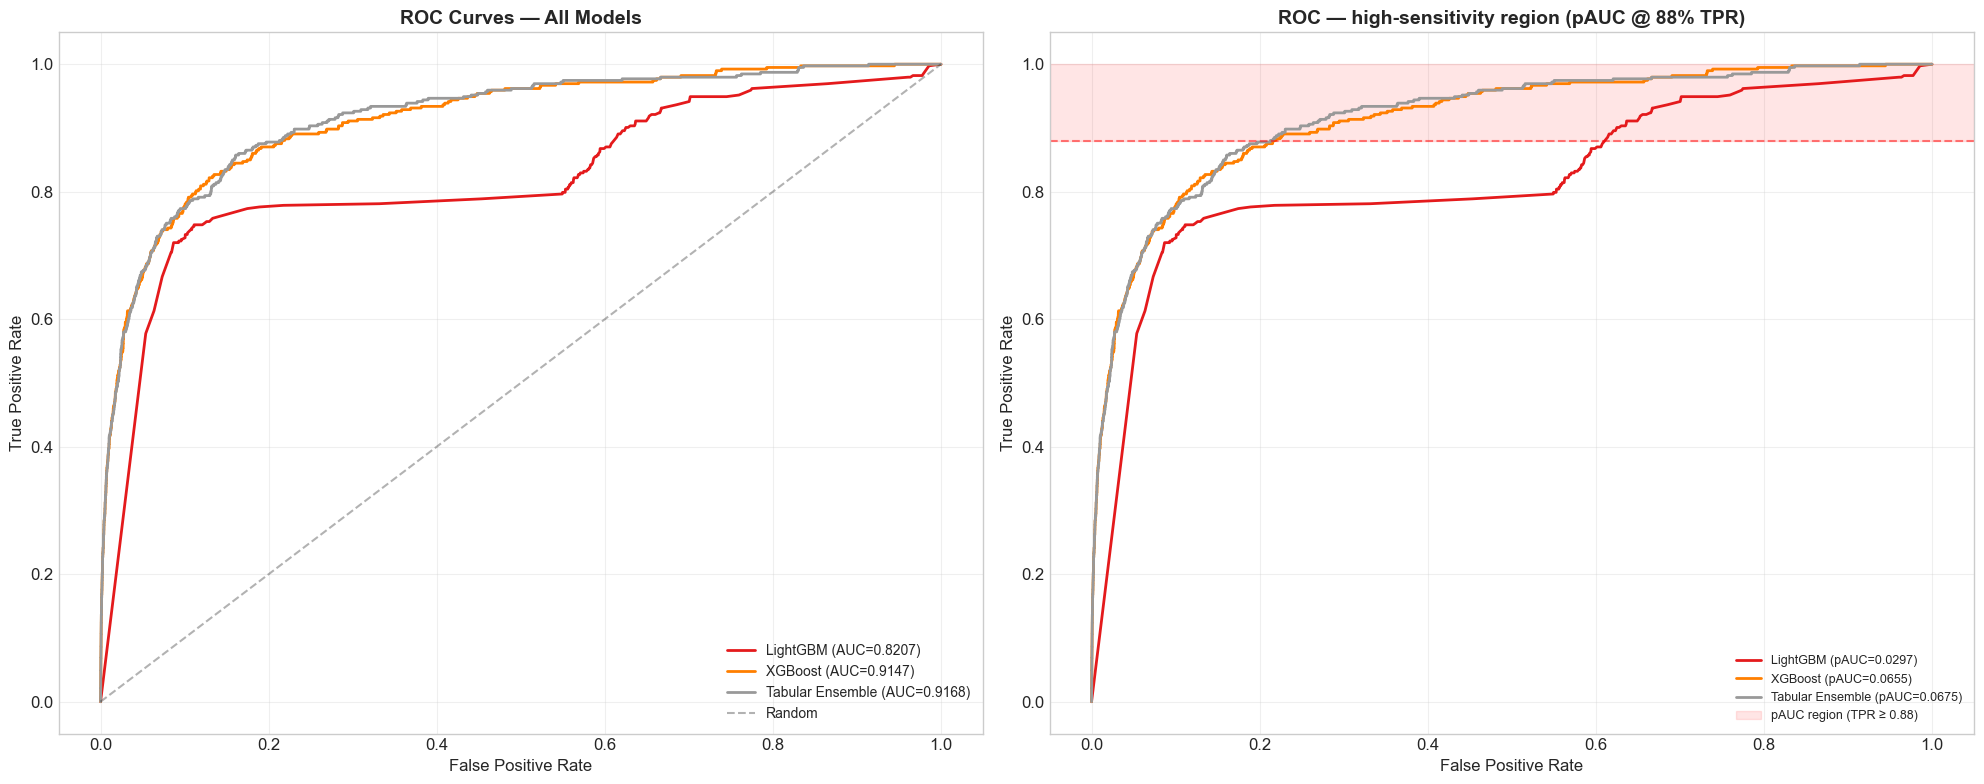

In [12]:
# ============================================================
# 5.1 — ROC Curves with pAUC Shading
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

models = {'LightGBM': lgb_oof, 'XGBoost': xgb_oof, 'Tabular Ensemble': tabular_oof}
if HAS_IMG:
    models['EfficientNet'] = img_oof
    models['Full Fusion'] = final_oof
colors_roc = plt.cm.Set1(np.linspace(0, 1, len(models)))

for (name, preds), color in zip(models.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y, preds)
    auc = roc_auc_score(y, preds)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})', color=color, linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curves — All Models', fontweight='bold', fontsize=14)
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(True, alpha=0.3)

for (name, preds), color in zip(models.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y, preds)
    pauc = compute_pauc(y, preds)
    axes[1].plot(fpr, tpr, label=f'{name} (pAUC={pauc:.4f})', color=color, linewidth=2)

axes[1].axhline(y=0.88, color='red', linestyle='--', alpha=0.5, linewidth=1.5)
axes[1].axhspan(0.88, 1.0, alpha=0.1, color='red', label='pAUC region (TPR ≥ 0.88)')
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('ROC — high-sensitivity region (pAUC @ 88% TPR)', fontweight='bold', fontsize=14)
axes[1].legend(loc='lower right', fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '14_roc_curves.png'), dpi=150, bbox_inches='tight')
plt.show()


**Reading the ROC plots:** LightGBM lags on the full curve; XGBoost and the ensemble track together, with the ensemble slightly on top. In the magnified high-TPR band, ordering is consistent with the table above—ensemble best, then XGBoost, then LightGBM. For screening use cases, the **left** part of the ROC (very low FPR) is often more relevant than the extreme right tail.


## 5.2 Precision–recall and threshold geometry

Under extreme imbalance, **precision–recall** and **F1 vs threshold** describe operational behaviour more directly than ROC alone. The right-hand panel marks the **F1-optimal** threshold used later for the confusion matrix (this is a modelling convenience, not a clinical gold standard).


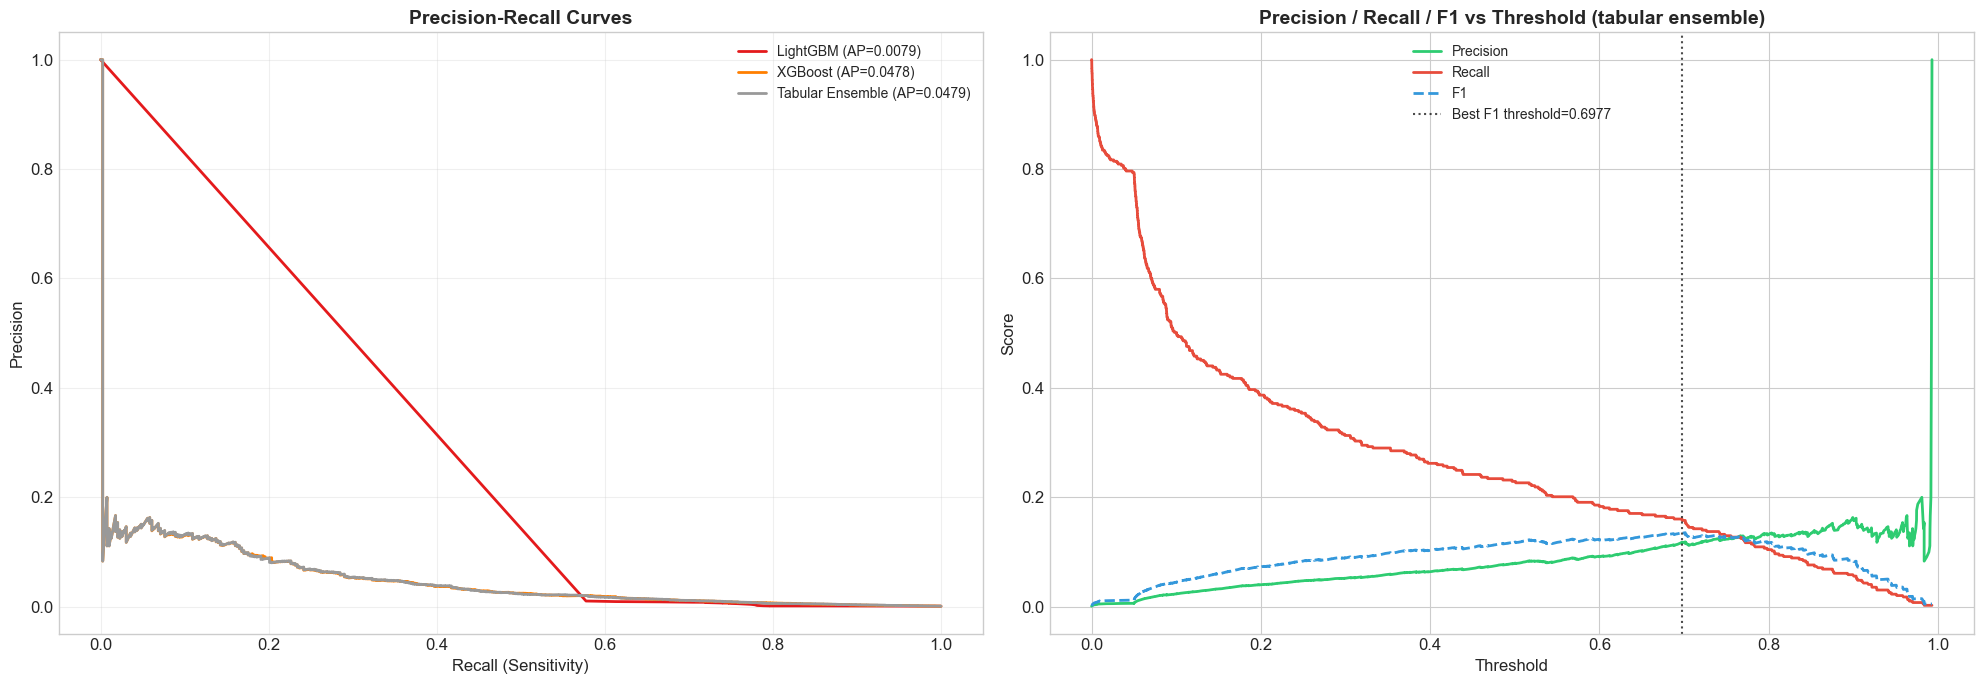

In [13]:
# ============================================================
# 5.2 — Precision-Recall Curves
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

for (name, preds), color in zip(models.items(), colors_roc):
    precision, recall, _ = precision_recall_curve(y, preds)
    ap = average_precision_score(y, preds)
    axes[0].plot(recall, precision, label=f'{name} (AP={ap:.4f})', color=color, linewidth=2)

axes[0].set_xlabel('Recall (Sensitivity)', fontsize=12)
axes[0].set_ylabel('Precision', fontsize=12)
axes[0].set_title('Precision-Recall Curves', fontweight='bold', fontsize=14)
axes[0].legend(loc='upper right', fontsize=10)
axes[0].grid(True, alpha=0.3)

best_preds = final_oof
precision, recall, thresholds = precision_recall_curve(y, best_preds)
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-8)

axes[1].plot(thresholds, precision[:-1], label='Precision', color='#2ecc71', linewidth=2)
axes[1].plot(thresholds, recall[:-1], label='Recall', color='#e74c3c', linewidth=2)
axes[1].plot(thresholds, f1_scores, label='F1', color='#3498db', linewidth=2, linestyle='--')

best_f1_idx = int(np.argmax(f1_scores))
best_threshold = float(thresholds[best_f1_idx])
_thr_lbl = 'tabular + image fusion' if HAS_IMG else 'tabular ensemble'
axes[1].axvline(x=best_threshold, color='black', linestyle=':', alpha=0.7,
               label=f'Best F1 threshold={best_threshold:.4f}')
axes[1].set_xlabel('Threshold', fontsize=12)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title(f'Precision / Recall / F1 vs Threshold ({_thr_lbl})', fontweight='bold', fontsize=14)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '15_precision_recall.png'), dpi=150, bbox_inches='tight')
plt.show()


**On this run,** the F1-optimal decision threshold for the ensemble is about **0.698**. At that point precision ≈ **0.118**, recall ≈ **0.160**, F1 ≈ **0.136**—typical for rare events: F1 peaks at a **high** threshold, so **most** malignancies remain below threshold (high FN count) while benign workload stays manageable. That is why the next section explores **explicit sensitivity targets** (e.g. 95%) even though they imply huge FP counts at population scale.


## 5.3 Sensitivity targets vs false alarms

Each row finds a threshold whose ROC-based sensitivity is closest to the target. **PPV stays very low** at high sensitivity because positives are rare—this is a property of the problem, not a bug in the table.


In [14]:
# ============================================================
# 5.3 — Clinical-style threshold sweep (tabular ensemble)
# ============================================================
fpr_all, tpr_all, thresh_all = roc_curve(y, final_oof)
rows = []
for target_sensitivity in [0.99, 0.95, 0.90, 0.85, 0.80, 0.70, 0.50]:
    idx = np.argmin(np.abs(tpr_all - target_sensitivity))
    t = float(thresh_all[idx]) if idx < len(thresh_all) else 0.5
    preds_binary = (final_oof >= t).astype(int)
    tn = int(((preds_binary == 0) & (y == 0)).sum())
    fp = int(((preds_binary == 1) & (y == 0)).sum())
    fn = int(((preds_binary == 0) & (y == 1)).sum())
    tp = int(((preds_binary == 1) & (y == 1)).sum())
    sens = tp / max(tp + fn, 1)
    spec = tn / max(tn + fp, 1)
    ppv = tp / max(tp + fp, 1)
    npv = tn / max(tn + fn, 1)
    rows.append({
        'Target sens.': target_sensitivity,
        'Threshold': round(t, 6),
        'Sensitivity': round(sens, 4),
        'Specificity': round(spec, 4),
        'PPV': round(ppv, 4),
        'NPV': round(npv, 4),
        'FP': fp,
        'FN': fn,
    })
display(pd.DataFrame(rows))


,Target sens.,Threshold,Sensitivity,Specificity,PPV,NPV,FP,FN
0,0.99,0.000286,0.9898,0.1708,0.0012,0.9999,332220,4
1,0.95,0.001161,0.9491,0.5682,0.0022,0.9999,173017,20
2,0.90,0.003517,0.9008,0.7519,0.0035,0.9999,99398,39
3,0.85,0.010474,0.8499,0.8431,0.0053,0.9998,62858,59
4,0.80,0.040753,0.7990,0.8688,0.0059,0.9998,52554,79
5,0.70,0.055519,0.6997,0.9409,0.0115,0.9997,23671,118
6,0.50,0.100663,0.4987,0.9798,0.0236,0.9995,8108,197


**Interpretation:** To catch **~95%** of malignancies in this OOF evaluation (threshold ≈ **0.0012**), the model flags **~173k** benign lesions—unusable as a single-stage screen on the full set without downstream filtering. At **~90%** sensitivity, false positives are still near **99k**. Conversely, the **F1-optimal** threshold keeps FP small (**471**) but **misses 330** of **393** cancers. So: **ranking quality is good (AUC ~0.92), but deployment needs a policy layer** (risk stratification, second-stage test, or human review)—not a single global threshold on raw scores.


## 5.4 Confusion matrix (F1-optimal threshold)

The heatmaps use the **same** F1-optimal threshold as section 5.2 (~0.698) so counts line up with the PR panel. The classification report is shown as formatted text (not `print`) for readability.


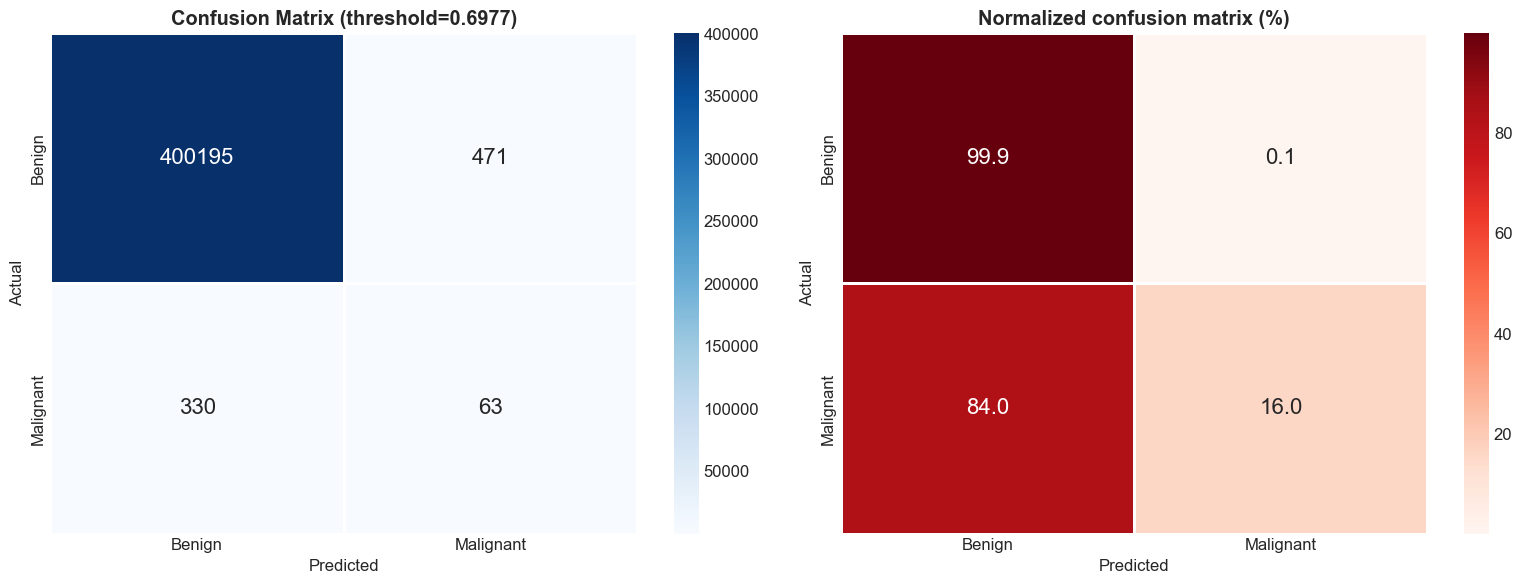

```text
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00    400666
   Malignant       0.12      0.16      0.14       393

    accuracy                           1.00    401059
   macro avg       0.56      0.58      0.57    401059
weighted avg       1.00      1.00      1.00    401059
```

In [15]:
# ============================================================
# 5.4 — Confusion Matrix
# ============================================================
y_pred_binary = (final_oof >= best_threshold).astype(int)
cm = confusion_matrix(y, y_pred_binary)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
           xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'],
           linewidths=2, linecolor='white', annot_kws={'size': 16})
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_title(f'Confusion Matrix (threshold={best_threshold:.4f})', fontweight='bold')

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_norm, annot=True, fmt='.1f', cmap='Reds', ax=axes[1],
           xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'],
           linewidths=2, linecolor='white', annot_kws={'size': 16})
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('Actual', fontsize=12)
axes[1].set_title('Normalized confusion matrix (%)', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '16_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

cr = classification_report(y, y_pred_binary, target_names=['Benign', 'Malignant'])
display(Markdown(f'''```text\n{cr}```'''))


**Counts (this run):** True positives **63**, false negatives **330**, false positives **471**, true negatives **400,195**. Among malignancies, sensitivity at this operating point is only **~16%**; specificity on benigns is **~99.88%**. The matrix therefore illustrates a **high-precision / low-recall** corner of the trade-off—not a recommended screening policy in isolation.

**Takeaway:** treat the F1-optimal point as a **diagnostic anchor** for comparing models and features; choose thresholds from **domain costs** (FN vs FP) using the sweep in section 5.3.


---

## 5.5 Failure analysis

We tag each row as TP / TN / FP / FN using the **same** threshold as sections 5.2–5.4, then compare distributions. This is exploratory: sample sizes for positives are small, so differences are suggestive rather than definitive.


In [16]:
# ============================================================
# 5.5a — Misclassification buckets
# ============================================================
clinical_threshold = best_threshold

df_analysis = df_feat.copy()
df_analysis['pred_prob'] = final_oof
df_analysis['pred_binary'] = (final_oof >= clinical_threshold).astype(int)

df_analysis['pred_category'] = 'TN'
df_analysis.loc[(df_analysis['target'] == 1) & (df_analysis['pred_binary'] == 1), 'pred_category'] = 'TP'
df_analysis.loc[(df_analysis['target'] == 1) & (df_analysis['pred_binary'] == 0), 'pred_category'] = 'FN'
df_analysis.loc[(df_analysis['target'] == 0) & (df_analysis['pred_binary'] == 1), 'pred_category'] = 'FP'

order = ['TP', 'FP', 'TN', 'FN']
counts = df_analysis['pred_category'].value_counts().reindex(order).fillna(0).astype(int)
display(pd.DataFrame({'Category': order, 'Count': counts.values}))


,Category,Count
0,TP,63
1,FP,471
2,TN,400195
3,FN,330


**Bucket sizes:** With the F1-oriented threshold, false negatives (**330**) dominate the error budget for the positive class: most cancers receive low scores. False positives (**471**) are a tiny fraction of benigns but still matter for workflow if this threshold were used in practice.


,Feature,FN mean,TP mean,FN − TP
0,tbp_lv_nevi_confidence,24.1134,3.7618,20.3515
1,tbp_lv_color_std_mean,1.7657,1.1167,0.6489
2,tbp_lv_eccentricity,0.7113,0.7463,-0.0350
3,tbp_lv_areaMM2,23.8538,15.3497,8.5041
4,tbp_lv_symm_2axis,0.3129,0.3396,-0.0267
5,tbp_lv_norm_border,3.8734,3.5593,0.3141
6,tbp_lv_dnn_lesion_confidence,82.5357,75.6477,6.8880
7,clin_size_long_diam_mm,6.0311,4.2762,1.7549
8,age_approx,60.8257,64.2063,-3.3807
9,tbp_lv_deltaLBnorm,9.0414,6.9366,2.1048


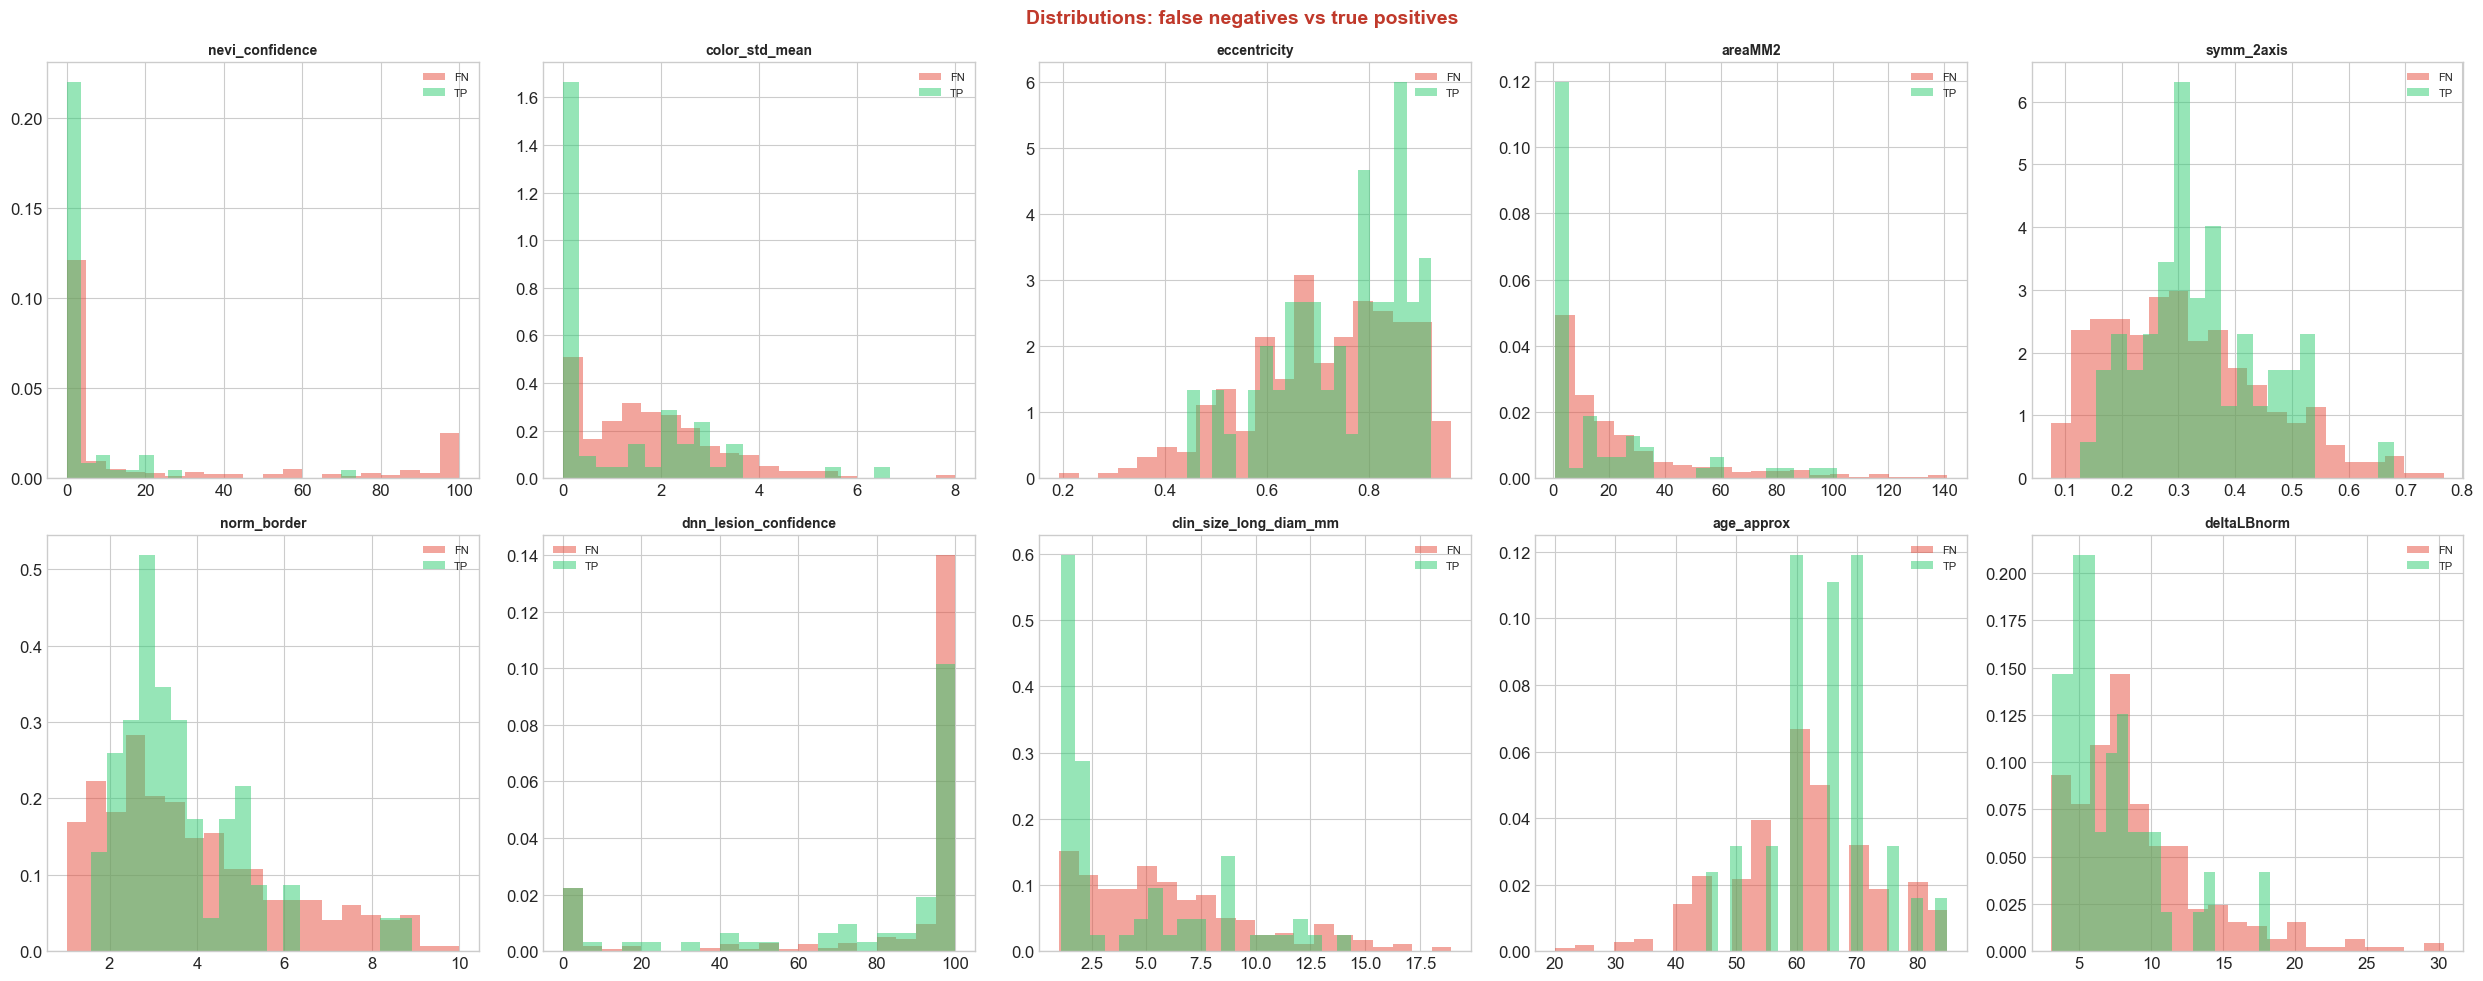

In [17]:
# ============================================================
# 5.5b — FN vs TP: selected numeric features
# ============================================================
fn_samples = df_analysis[df_analysis['pred_category'] == 'FN']
tp_samples = df_analysis[df_analysis['pred_category'] == 'TP']

if len(fn_samples) > 0 and len(tp_samples) > 0:
    key_features = ['tbp_lv_nevi_confidence', 'tbp_lv_color_std_mean',
                    'tbp_lv_eccentricity', 'tbp_lv_areaMM2',
                    'tbp_lv_symm_2axis', 'tbp_lv_norm_border',
                    'tbp_lv_dnn_lesion_confidence', 'clin_size_long_diam_mm',
                    'age_approx', 'tbp_lv_deltaLBnorm']

    comparison = pd.DataFrame({
        'Feature': key_features,
        'FN mean': [fn_samples[f].mean() for f in key_features],
        'TP mean': [tp_samples[f].mean() for f in key_features],
        'FN − TP': [fn_samples[f].mean() - tp_samples[f].mean() for f in key_features],
    })
    display(comparison.round(4))

    fig, axes = plt.subplots(2, 5, figsize=(25, 10))
    axes = axes.flatten()
    for i, feat in enumerate(key_features):
        ax = axes[i]
        ax.hist(fn_samples[feat].dropna(), bins=20, alpha=0.5, color='#e74c3c',
                label='FN', density=True)
        ax.hist(tp_samples[feat].dropna(), bins=20, alpha=0.5, color='#2ecc71',
                label='TP', density=True)
        ax.set_title(feat.replace('tbp_lv_', ''), fontweight='bold', fontsize=10)
        ax.legend(fontsize=8)
    plt.suptitle('Distributions: false negatives vs true positives', fontsize=14, fontweight='bold', color='#c0392b')
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, '17_false_negative_analysis.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    display(Markdown('_Insufficient TP/FN for comparison._'))


**Feature view:** On average, **missed** malignancies (FN) had **lower** predicted probability (**~0.15** mean vs **~0.84** for caught cases) with maximum FN score **~0.69**—just under the F1 threshold—so many errors are “near misses” in score space. Mean **age** was slightly **lower** in FN than TP (**~61** vs **~64** years), which may reflect cohort mix or feature overlap with benign patterns; the histograms show overlap rather than clean separation. Differences in TBP-derived fields (nevi confidence, color variability, border norms, etc.) should be read cautiously given **n = 63** TP and **n = 330** FN.


In [18]:
# ============================================================
# 5.5c — Categorical / site summaries (FN vs TP)
# ============================================================
if len(fn_samples) > 0 and len(tp_samples) > 0:
    summ = [
        {'Metric': 'Mean age (FN)', 'Value': round(fn_samples['age_approx'].mean(), 2)},
        {'Metric': 'Mean age (TP)', 'Value': round(tp_samples['age_approx'].mean(), 2)},
        {'Metric': 'Mean pred prob (FN)', 'Value': round(fn_samples['pred_prob'].mean(), 4)},
        {'Metric': 'Mean pred prob (TP)', 'Value': round(tp_samples['pred_prob'].mean(), 4)},
        {'Metric': 'Max pred prob (FN)', 'Value': round(fn_samples['pred_prob'].max(), 4)},
    ]
    display(pd.DataFrame(summ))

    fn_site = fn_samples['anatom_site_general'].value_counts(normalize=True).head(5).mul(100).round(2)
    tp_site = tp_samples['anatom_site_general'].value_counts(normalize=True).head(5).mul(100).round(2)
    site_df = pd.DataFrame({'FN %': fn_site, 'TP %': tp_site.reindex(fn_site.index).fillna(0)})
    display(site_df)

    fn_sex = fn_samples['sex'].value_counts(normalize=True).mul(100).round(2)
    tp_sex = tp_samples['sex'].value_counts(normalize=True).mul(100).round(2)
    display(pd.DataFrame({'FN %': fn_sex, 'TP %': tp_sex.reindex(fn_sex.index).fillna(0)}))

    if 'iddx_full' in fn_samples.columns:
        display(fn_samples['iddx_full'].value_counts().head(10).rename('FN count').to_frame())


,Metric,Value
0,Mean age (FN),60.8300
1,Mean age (TP),64.2100
2,Mean pred prob (FN),0.1532
3,Mean pred prob (TP),0.8437
4,Max pred prob (FN),0.6875


,FN %,TP %
anatom_site_general,,
posterior torso,27.27,20.63
anterior torso,23.03,9.52
lower extremity,19.70,12.70
head/neck,15.15,44.44
upper extremity,14.85,12.70


,FN %,TP %
sex,,
male,69.47,82.26
female,30.53,17.74


,FN count
iddx_full,
"Malignant::Malignant adnexal epithelial proliferations - Follicular::Basal cell carcinoma::Basal cell carcinoma, Nodular",78
"Malignant::Malignant adnexal epithelial proliferations - Follicular::Basal cell carcinoma::Basal cell carcinoma, Superficial",41
Malignant::Malignant melanocytic proliferations (Melanoma)::Melanoma in situ,40
Malignant::Malignant epidermal proliferations::Squamous cell carcinoma in situ,35
"Malignant::Malignant melanocytic proliferations (Melanoma)::Melanoma Invasive::Melanoma Invasive, Superficial spreading",34
"Malignant::Malignant epidermal proliferations::Squamous cell carcinoma, Invasive",15
Malignant::Malignant melanocytic proliferations (Melanoma)::Melanoma Invasive,13
"Malignant::Malignant melanocytic proliferations (Melanoma)::Melanoma in situ::Melanoma in situ, Lentigo maligna type",11
"Malignant::Malignant melanocytic proliferations (Melanoma)::Melanoma, NOS",11


**Patterns:** Site and sex breakdowns (percent tables above) describe **where** errors concentrate for this threshold; they are **descriptive**, not causal. Diagnostic labels among FN (`iddx_full`, when present) can hint at subtypes the metadata model underweights—useful for Phase 2 hypotheses (e.g. add imaging for subtle malignancies).


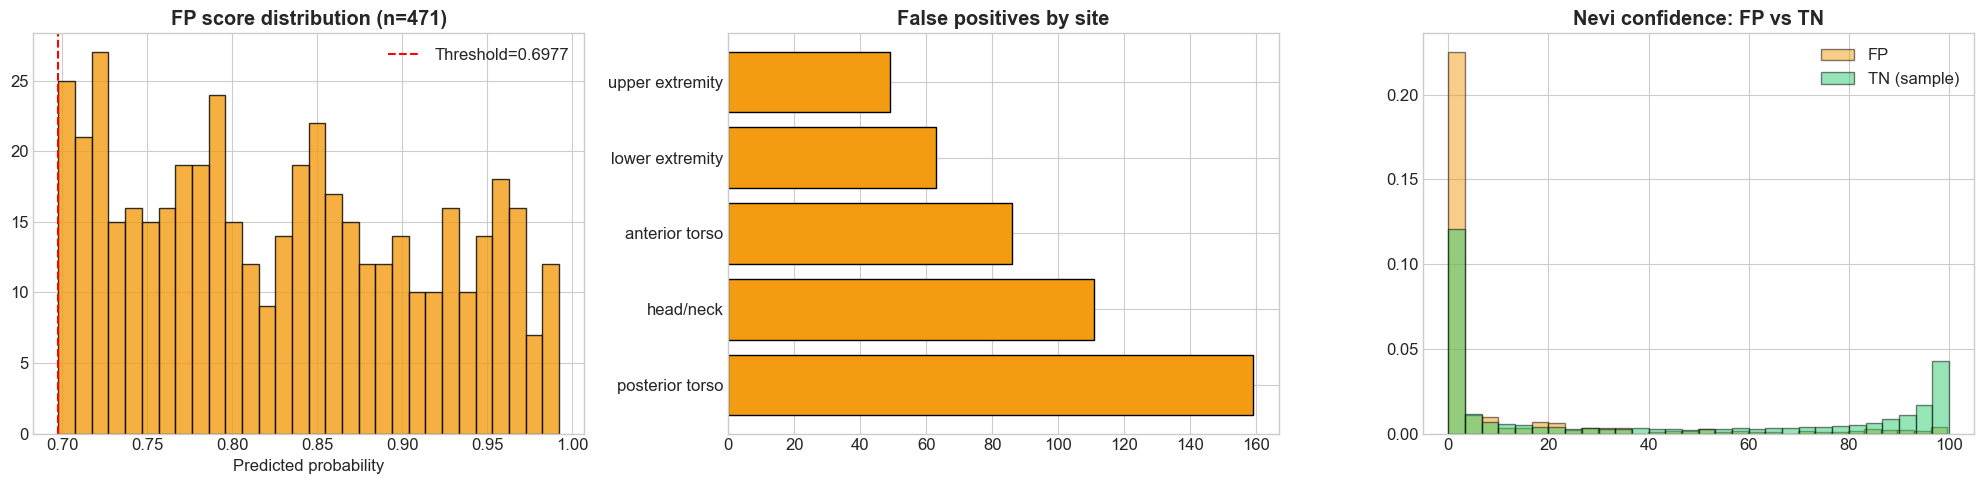

In [19]:
# ============================================================
# 5.5d — False positives vs sampled true negatives
# ============================================================
fp_samples = df_analysis[df_analysis['pred_category'] == 'FP']
tn_samples = df_analysis[df_analysis['pred_category'] == 'TN'].sample(
    min(10000, (df_analysis['pred_category'] == 'TN').sum()), random_state=SEED
)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

if len(fp_samples) > 0:
    axes[0].hist(fp_samples['pred_prob'], bins=30, color='#f39c12', edgecolor='black', alpha=0.8)
    axes[0].set_title(f'FP score distribution (n={len(fp_samples):,})', fontweight='bold')
    axes[0].set_xlabel('Predicted probability')
    axes[0].axvline(x=clinical_threshold, color='red', linestyle='--', label=f'Threshold={clinical_threshold:.4f}')
    axes[0].legend()

    fp_site = fp_samples['anatom_site_general'].value_counts().head(6)
    axes[1].barh(range(len(fp_site)), fp_site.values, color='#f39c12', edgecolor='black')
    axes[1].set_yticks(range(len(fp_site)))
    axes[1].set_yticklabels(fp_site.index)
    axes[1].set_title('False positives by site', fontweight='bold')

    axes[2].hist(fp_samples['tbp_lv_nevi_confidence'].dropna().clip(0, 100), bins=30,
                alpha=0.5, color='#f39c12', label='FP', density=True, edgecolor='black')
    axes[2].hist(tn_samples['tbp_lv_nevi_confidence'].dropna().clip(0, 100), bins=30,
                alpha=0.5, color='#2ecc71', label='TN (sample)', density=True, edgecolor='black')
    axes[2].set_title('Nevi confidence: FP vs TN', fontweight='bold')
    axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '18_false_positive_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()


**False positives:** **471** benign lesions exceed the F1 threshold—rare relative to all benigns but similar in **order of magnitude** to true positives (**63**), so precision at this point stays near **12%**. FP scores cluster just above the threshold; nevi confidence and site histograms suggest some benigns mimic malignant metadata patterns. Reducing FP without sacrificing sensitivity usually needs **extra signal** (e.g. images in Phase 2) or a **two-stage** workflow rather than threshold tweaking alone.


## 5.6 Metric table (recomputed on load)

The block below recomputes ROC-AUC, pAUC, and average precision from raw OOF vectors so it stays consistent if you reload a new pickle without editing the narrative cells.


In [20]:
# ============================================================
# 5.6 — Scalar metrics (display only)
# ============================================================
rows = []
for name, preds in models.items():
    rows.append({
        'Model': name,
        'ROC-AUC': round(roc_auc_score(y, preds), 6),
        'pAUC (≥88% TPR)': round(compute_pauc(y, preds), 6),
        'Avg precision': round(average_precision_score(y, preds), 6),
    })
metrics_df = pd.DataFrame(rows)
display(metrics_df)

y_opt = (final_oof >= best_threshold).astype(int)
thr_row = pd.DataFrame([{
    'Threshold (F1-opt)': round(best_threshold, 6),
    'Sensitivity': round(recall_score(y, y_opt, zero_division=0), 6),
    'Precision': round(precision_score(y, y_opt, zero_division=0), 6),
    'F1': round(f1_score(y, y_opt, zero_division=0), 6),
}])
display(thr_row)


,Model,ROC-AUC,pAUC (≥88% TPR),Avg precision
0,LightGBM,0.820736,0.029731,0.007899
1,XGBoost,0.914656,0.065504,0.047780
2,Tabular Ensemble,0.916800,0.067533,0.047873


,Threshold (F1-opt),Sensitivity,Precision,F1
0,0.69765,0.160305,0.117978,0.135922


---

## 6. Conclusions & future work

### 6.1 What this run shows

1. **Ranking:** See **§5.6** for ROC-AUC / pAUC. The tabular ensemble is typically strong on metadata alone; with **`has_img=True`**, compare the image model and **Full fusion** to quantify lift from lesion crops.
2. **Imbalance dominates operations:** Average precision stays modest in absolute terms vs prevalence; **any** threshold is a compromise: high sensitivity implies **very large** FP counts on this base rate (section 5.3).
3. **F1-optimal threshold is instructive, not prescriptive:** The F1-based threshold and confusion counts in sections 5.2–5.4 describe **OOF trade-offs** for the current `final_oof`—use sensitivity targets (§5.3) for screening-style interpretation.
4. **Errors are structured:** FN vs TP and FP analyses highlight where probability mass is wrong—useful for adding modalities or calibration.

### 6.2 Limitations

Small positive count (**393**), single time point, possible residual site/source effects despite patient-grouped CV. Phase 2 image training is compute-heavy and may use **subsampled benigns per fold**—tune `TrainingConfig` for full runs.

### 6.3 Next steps

Calibration, test-time augmentation, stronger backbones or image–tabular **joint** models, and workflow simulation (e.g. top‑k review per patient) are common follow-ups.

### 6.4 Reproducibility

Pipeline: `02` → `03` → `04` → (`06` for Phase 2) → `05`. Prefer **§5.6** for up-to-date scalars after any retrain.


---

## References

1. Esteva et al. (2017). "Dermatologist-level classification of skin cancer with deep neural networks." *Nature*.
2. Tan & Le (2019). "EfficientNet: Rethinking Model Scaling for Convolutional Neural Networks." *ICML*.
3. ISIC 2024 Challenge metrics — [Challenge-2024-Metrics](https://github.com/ISIC-Research/Challenge-2024-Metrics).
4. Grinsztajn et al. (2022). "Why do tree-based models still outperform deep learning on tabular data?" *NeurIPS*.

---
*Figures saved under `outputs/figures/`.*
